In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, quantity_support
plt.style.use(astropy_mpl_style)
quantity_support() 
import astropy.units as u
from astropy.time import Time
from datetime import datetime, timedelta
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
import math
import astroplan as apl
import seaborn as sns
import pandas as pd
KECK_LAT = 19.8260 #[deg]
KECK_ELEVATION = 4.1449752 # km
RADIUS_EARTH = 6378.1000 # km
ATMOSPHERE_HEIGHT = 50.000 # km
KECK_LONG = 360 - 155.4747 

def date_to_juld(date):
    return (date.timestamp() / 86400) + 2440587.5 #do not offset
    #return (date.timestamp() / 86400)

def get_gmt(date=None):
    if date is None:
        date = datetime.now()
    JD = date_to_juld(date)
    T = (JD - 2451545) / 36525
    ThetaGMST = 67310.54841 + (876600 * 3600 + 8640184.812866) * T + .093104 * (T**2) - (6.2 * 10**-6) * (T**3)
    ThetaGMST = (ThetaGMST % (86400 * (ThetaGMST / abs(ThetaGMST))) / 240) % 360

    return ThetaGMST

def cosd(deg):
    return math.cos(math.pi / 180 * deg)

def sind(deg):
    return math.sin(math.pi / 180 * deg)

def tand(deg):
    return math.tan(math.pi / 180 * deg)

def ra_dec_to_az_alt(ra, dec, date=None):
    if date is None:
        date = datetime.now()
    lngLatEl = { 'lng': KECK_LONG, 'lat': KECK_LAT, 'ele': KECK_ELEVATION }
    hourAngle = (get_gmt(date) + lngLatEl['lng'] - ra) % 360
    tanAzNum = sind(hourAngle)
    tanAzDen = cosd(hourAngle) * sind(lngLatEl['lat']) - tand(dec) * cosd(lngLatEl['lat'])
    az = math.atan2(tanAzNum, tanAzDen) + math.pi
    sinEl = sind(lngLatEl['lat']) * sind(dec) + cosd(lngLatEl['lat']) * cosd(dec) * cosd(hourAngle)
    el = math.asin(sinEl)
    return [(180 / math.pi * az), (180 / math.pi * el)]

ra = 10.0
dec = 10.0
date = datetime.now()
py_az_alt = ra_dec_to_az_alt(ra, dec, date)

keck = EarthLocation(lat=KECK_LAT*u.deg, lon=KECK_LONG*u.deg, height=KECK_ELEVATION*u.m)
coord = SkyCoord(ra=ra * u.degree, dec=dec * u.degree, frame='icrs')

#coord = SkyCoord(ra * u.hourangle, dec * u.deg, frame="icrs")
target = apl.FixedTarget(name='tgt', coord=coord)
time = Time(date +timedelta(hours=10))
ap_alt_az = coord.transform_to(AltAz(obstime=time,location=keck))

keckap = apl.Observer.at_site("W. M. Keck Observatory")
altaz = keckap.altaz(date, target, grid_times_targets=True)
print(date)
print(py_az_alt[1])
print(ap_alt_az.alt.value)
print(altaz.az.value)


2024-04-04 08:53:46.932856
42.32846002975162
42.07795688105027
[[326.08523439]]


In [2]:
%%timeit
ra_dec_to_az_alt(ra, dec, date)

3.71 µs ± 61.1 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [3]:
%%timeit
coord.transform_to(AltAz(obstime=Time(date, scale='utc'),location=keck))

3.25 ms ± 130 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [4]:
%%timeit
keckap.altaz(date, target, grid_times_targets=True)

4.72 ms ± 450 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [21]:
from random import randrange
from datetime import timedelta
d1 = datetime.strptime('1/1/2008 1:30 PM', '%m/%d/%Y %I:%M %p')
d2 = datetime.strptime('1/1/2039 4:50 AM', '%m/%d/%Y %I:%M %p')


def random_date(start, end):
    """
    This function will return a random datetime between two datetime 
    objects.
    """
    delta = end - start
    int_delta = (delta.days * 24 * 60 * 60) + delta.seconds
    random_second = randrange(int_delta)
    return start + timedelta(seconds=random_second)

data = []
for _ in range(10**4):
    date = random_date(d1, d2)
    ra = np.random.uniform(0, 360)
    dec = np.random.uniform(-90, 90)
    coord = SkyCoord(ra=ra * u.degree, dec=dec * u.degree, frame='icrs')
    target = apl.FixedTarget(name='tgt', coord=coord)
    time = Time(date +timedelta(hours=10))
    ap_alt_az = coord.transform_to(AltAz(obstime=time,location=keck))
    py_alt_az = ra_dec_to_az_alt(ra, dec, date)
    datum = {
        'ra': ra, 'dec': dec, 'date': date,
        'ap_az': ap_alt_az.az.value, 'ap_alt': ap_alt_az.alt.value,
        'py_alt': py_az_alt[1], 'py_az': py_az_alt[0],
        'alt_err': py_alt_az[1] - ap_alt_az.alt.value,
        'az_err': py_alt_az[0] - ap_alt_az.az.value,
    }
    # data.append({
    #     'ra': ra, 'dec': dec, 'date': date, 'model': 'astropy',
    #     'az': ap_alt_az.az.value })
    # data.append({
    #     'ra': ra, 'dec': dec, 'date': date, 'model': 'tyler',
    #     'az': py_alt_az[0] })

    data.append(datum)

/home/tyler/anaconda3/envs/firstEnv/lib/python3.10/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),
/home/tyler/anaconda3/envs/firstEnv/lib/python3.10/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),
/home/tyler/anaconda3/envs/firstEnv/lib/python3.10/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "utcut1" yielded 1 of "dubious year (Note 3)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),
/home/tyler/anaconda3/envs/firstEnv/lib/python3.10/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


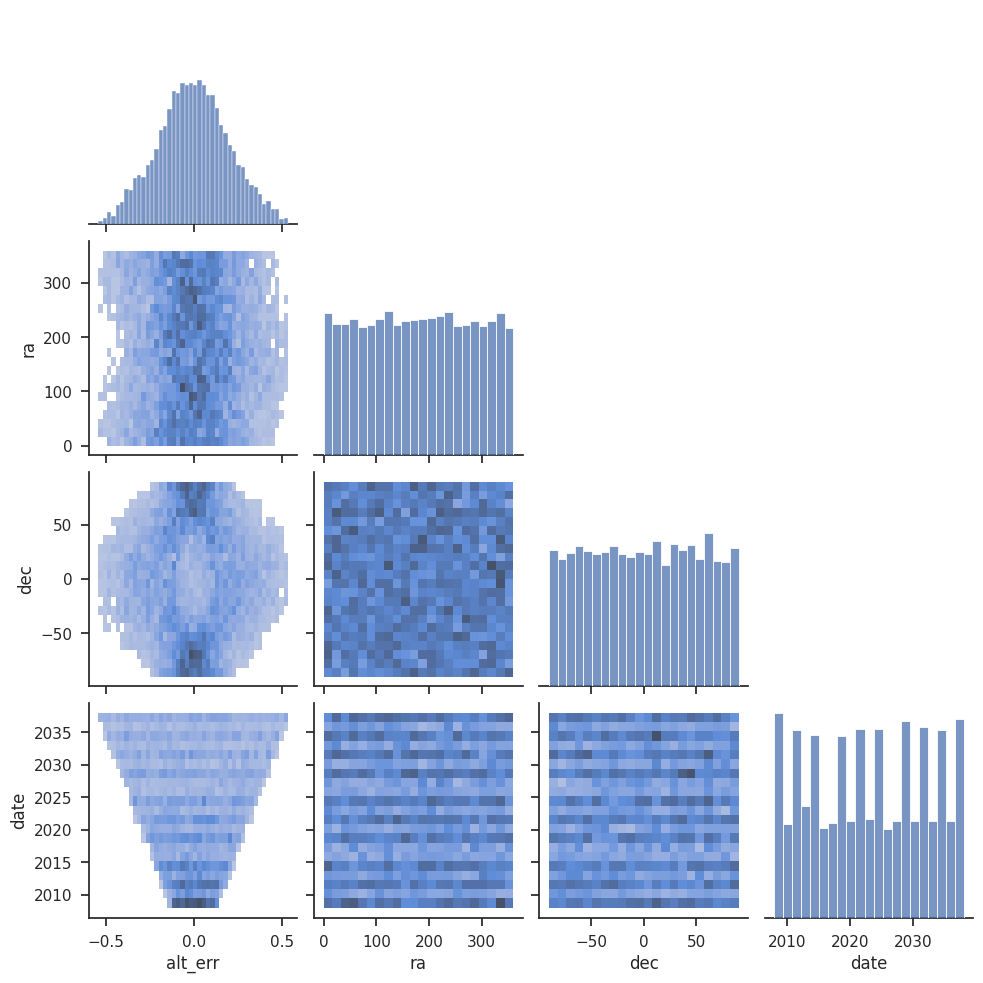

In [44]:
import seaborn as sns
import pandas as pd
sns.set_theme(style="ticks")

#df = sns.load_dataset("penguins")
df = pd.DataFrame(data)
df = df[['alt_err', 'ra','dec', 'date']]
df["date"] = df["date"].dt.year
sns.pairplot(df, kind="hist", corner=True)
#sns.boxplot(y='az_err',data=df)
#sns.histplot(data=df, x="alt_err")

In [35]:
df.head()

,ra,dec,date,alt_err
0,336.182920,-89.952182,2016-05-06 04:30:07,-0.033118
1,2.636493,77.261149,2012-01-07 20:51:38,0.010019
2,309.960071,-29.219163,2030-11-23 07:08:16,0.420012
3,105.591695,49.119313,2023-11-22 18:18:18,0.230653
4,333.869286,51.339489,2031-04-22 11:00:17,-0.068474
